# 第４回 numpyとmatplotlib
numpyとmatplotlibの話になるよ～少し長いかも

## 4-1. numpy
- 効率的に多次元の配列を扱うことができる。
- 高速な行列演算が可能になるため、行列演算を行う科学技術計算などでよく活用される

In [1]:
import numpy as np

### 4-1-1 配列作成

In [2]:
# array () 関数で配列作成
list_to_array = np.array([1,2,3,4,5])
list_to_array

array([1, 2, 3, 4, 5])

In [3]:
# ndarrayオブジェクトとなる
tuple_to_array = np.array((1,2,3,4,5))
type(tuple_to_array)

numpy.ndarray

In [4]:
# print()で要素が空白区切り
print(list_to_array)
print(tuple_to_array)

[1 2 3 4 5]
[1 2 3 4 5]


### array()
- 第二引数で要素の型を指定できる。ただ混同はできない
- `.dtype()`で型を確認できる
- 一回指定した型も上書きできる

In [5]:
list_to_array = np.array([1,2,3,4,5], dtype = float)
list_to_array.dtype

dtype('float64')

### 4-1-2 多次元配列の作成
配列の中の配列

In [6]:
mul_array = np.array([[1,2,3], [4,5,6]])
print(mul_array)

# 行数と列数
print(mul_array.shape)

# 次元数
print(mul_array.ndim)

# 要素数
print(mul_array.size)

[[1 2 3]
 [4 5 6]]
(2, 3)
2
6


In [7]:
# reshape()で1次元配列を2次元配列に
a = [1,2,3,4,5,6]
a1 = np.array(a)
a2 = a1.reshape(2,3)

print(a1)
print(a2)

[1 2 3 4 5 6]
[[1 2 3]
 [4 5 6]]


In [8]:
# 1行1列の要素に代入(1,1)の値を1から0に変更
a2[0,0] = 0

print(a1)
print(a2)

# 多次元配列を1次元配列に戻すravel()
print(a2.ravel())

[0 2 3 4 5 6]
[[0 2 3]
 [4 5 6]]
[0 2 3 4 5 6]


### 練習
以下のリストから1次元リストを作成し、その後３＊３の多次元配列を作成してください。shapeで属性確認をしてください

In [9]:
mylist = [1,2,3,4,5,6,7,8,9]

m1 = np.array(mylist)
m = m1.reshape(3,3)
print(m)

print(m.shape)

[[1 2 3]
 [4 5 6]
 [7 8 9]]
(3, 3)


### 4-1-3 様々な配列の作り方

#### `zeros()`関数
全要素が0の配列作成

In [10]:
zero_array1 = np.zeros(5, dtype=int)

# 5要素すべてが0の1次元配列
print(zero_array1)

# 3*3がすべて0の多次元配列
zero_array2 = np.zeros((3,3), dtype=int)
print(zero_array2)

[0 0 0 0 0]
[[0 0 0]
 [0 0 0]
 [0 0 0]]


#### `ones()`関数
すべてが1の配列作成

In [11]:
one_array1 = np.ones((2,2), dtype=int)
print(one_array1)

[[1 1]
 [1 1]]


#### `arrange()`関数
- 開始値から一定の刻み幅で生成した要素の配列作成
- 第一引数が開始値、第二が終了値、第三が刻み幅、任意で第四でstype=で型指定できるお

In [12]:
# 0~4の5要素の一次元配列
a1 = np.arange(5)
print(a1)

# ０から0.1刻みで1未満の要素を持つ配列
a2 = np.arange(0,1, 0.1)
print(a2)

# 0から1刻みで4要素配列をもつ2*2の多次元配列
a3 = np.arange(2*2).reshape(2,2)
print(a3)

[0 1 2 3 4]
[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]
[[0 1]
 [2 3]]


#### `linspace()`関数
範囲をちょうど分割する値の配列を作成

In [13]:
a4 = np.linspace(0,100,11)
print(a4)

[  0.  10.  20.  30.  40.  50.  60.  70.  80.  90. 100.]


#### `random.rand()`関数
乱数生成した配列を作成


In [14]:
rand_array = np.random.rand(5)
print(rand_array)

[0.58239441 0.69433868 0.19652329 0.71609367 0.2755789 ]


In [15]:
mu, sigma = 0,1
rand_normal_array = sigma *np.random.rand(10) + mu
print(rand_normal_array)



[0.0760903  0.20191135 0.96404148 0.90882876 0.79507198 0.37490242
 0.56912044 0.1803647  0.87311364 0.56163233]


### 4-1-4 csvファイルから配列作成

- `loadtxt()`でcsvを多次元配列で格納することができる。つかうんか？これ実務ではdfだからなあ

In [16]:
score = np.loadtxt("data/simple_score.csv", delimiter=",", skiprows= 1)
# sliprowsしているのは配列に違う型要素入れられないから科目名のrowをスキップ
score

array([[  1.,  30.,  43.,  51.,  63.],
       [  2.,  39.,  21.,  49.,  56.],
       [  3.,  29.,  30.,  23.,  57.],
       [  4.,  95.,  87.,  77., 100.],
       [  5.,  70.,  71.,  78.,  67.]])

### 4-1-5 配列要素の操作

#### インデックス
リストと同じ、0から始まるし、-xでうしろから指定できる

In [17]:
a = np.array([1,3,5,7,9])
print(a)

print(a[0])
print(a[-1])

# インデックス指定で上書き
a[-1] = 0
print(a)

[1 3 5 7 9]
1
9
[1 3 5 7 0]


#### 多次元配列
- `[ [], []]`この形式やね、見たことある

In [18]:
a = np.array([[1,2,3],
              [4,5,6]])
print(a)

# 行列の要素を指定（2行目, 3列目）の6が帰る
print(a[1,2])

# 代入
a[1,2] = 0
print(a)

[[1 2 3]
 [4 5 6]]
6
[[1 2 3]
 [4 5 0]]


In [19]:
score = np.loadtxt("data/simple_score.csv", delimiter=",", skiprows= 1)
print(score)

# 3行4列の要素
print(score[2,3])

[[  1.  30.  43.  51.  63.]
 [  2.  39.  21.  49.  56.]
 [  3.  29.  30.  23.  57.]
 [  4.  95.  87.  77. 100.]
 [  5.  70.  71.  78.  67.]]
23.0


### 4-1-6 スライス
array[開始位置:終了位置:ステップ]


In [20]:
a = np.array([1,100,1000,10000])
print(a)
print(a[1:4])
print(a[2:])
print(a[:-2])

# 最初から最後まで一個飛ばし
print(a[::2])
# 反対から最初までを順繰り
print(a[::-1])

[    1   100  1000 10000]
[  100  1000 10000]
[ 1000 10000]
[  1 100]
[   1 1000]
[10000  1000   100     1]


In [21]:
# すらいすでまとめて代入
a = np.array([1,10,100,1000,10000])
print(a)

a[1:4] = 0
print(a)

[    1    10   100  1000 10000]
[    1     0     0     0 10000]


In [22]:
# 多次元配列は次元毎にスライスを指定するお
a = np.array([1,2,3,4,5,6,7,8,9]).reshape(3,3)
print(a)

# 0~2までの行列をスライス
print(a[:2,:2])

# 2行2列以降をスライス
print(a[1:,1:])

[[1 2 3]
 [4 5 6]
 [7 8 9]]
[[1 2]
 [4 5]]
[[5 6]
 [8 9]]


### 4-1-7 要素順序の取り出し
- `for in` を使って配列要素を順番に取り出すことができりゅ

- `enumerate ()` 関数を使うと、リストと同じく、取り出しの繰り返し回数も併せて数えることができりゅ

- 多次元配列の要素の取り出しでは`ndenumerate()` 関数を用います。 

In [23]:
a1 = np.array([1,2,3,4,5,6])

for num in a1:
  print(num)

1
2
3
4
5
6


In [24]:
a2 = np.array([1,2,3,4,5,6]).reshape(2,3)

# これはインデックスごとの表示
for i, num in enumerate(a2):
  print(i,num)

# 要素ごとの座標とともに値を表示
for i,num in np.ndenumerate(a2):
  print(i, num)

0 [1 2 3]
1 [4 5 6]
(0, 0) 1
(0, 1) 2
(0, 2) 3
(1, 0) 4
(1, 1) 5
(1, 2) 6


### 4-1-8 要素の並び替え
　sort()




In [25]:
a1 = np.array([5,4,3,2,1])
a1.sort()
print(a1)

a2 = np.array([5,3,4,2,1])
a3 = np.sort(a2)

print(a2)
print(a3)

[1 2 3 4 5]
[5 3 4 2 1]
[1 2 3 4 5]


### 4-1-9 要素の条件取り出し


In [26]:
a1 = np.array([1,2,-3,-4,5,-6,-7])
print(a1>0)

a2 = a1[a1>0]
print(a2)

[ True  True False False  True False False]
[1 2 5]


In [27]:
score = np.loadtxt("data/simple_score.csv", delimiter=",", skiprows=1)
# 特典列だけ抽出
score = score[:,1:]

print(score)
print(score.mean())
# 各列
print(score.mean(0))
# 各行
print(score.mean(1))


[[ 30.  43.  51.  63.]
 [ 39.  21.  49.  56.]
 [ 29.  30.  23.  57.]
 [ 95.  87.  77. 100.]
 [ 70.  71.  78.  67.]]
56.8
[52.6 50.4 55.6 68.6]
[46.75 41.25 34.75 89.75 71.5 ]


### 4-1-10 配列同士の演算
各要素同士の演算

In [28]:
A = np.array([1,2,3,4]).reshape(2,2)
B = np.array([2,4,6,8]).reshape(2,2)

C = A+B
print(C)

D = A-B
print(D)

E = A*B
print(E)

F = A//B
print(F)

[[ 3  6]
 [ 9 12]]
[[-1 -2]
 [-3 -4]]
[[ 2  8]
 [18 32]]
[[0 0]
 [0 0]]


### 4-1-11 ブロードキャスト
GCIでやったやつ、インデックスたりないのを同じ要素を繰り返しで補完

In [29]:
A = np.array([1,2,3,4]).reshape(2,2)
B = np.array([2,4])

C=A+B
print(C)

[[3 6]
 [5 8]]


### 4-1-12 行列演算
内積とか行列積とか、線形代数でやった通り、行と列が同じである必要あり

- `dot()`で

- NumPyでは、行列の分解、転置、行列式などの計算を含む線形代数の機能は、 numpy.linalg モジュールで提供

In [30]:
A = np.array([1,2,3,4]).reshape(2,2)
B = np.array([2,4,6,8]).reshape(2,2)

C = np.dot(A,B)
print(C)

[[14 20]
 [30 44]]


In [31]:
# 単位行列
E = np.identity(3, dtype=int)
print(E)

[[1 0 0]
 [0 1 0]
 [0 0 1]]


In [32]:
# 転置
A = np.array([1,2,3,4,5,6]).reshape(2,3)

print(A)
print(np.transpose(A))

[[1 2 3]
 [4 5 6]]
[[1 4]
 [2 5]
 [3 6]]


In [33]:
print(A)
print(A.T)

[[1 2 3]
 [4 5 6]]
[[1 4]
 [2 5]
 [3 6]]


In [36]:
score = np.loadtxt("data/simple_score.csv", delimiter=",", skiprows=1)
score = score[:,1:]
print(score)

a = np.array([1,2,3,4])

A = np.dot(score,a)

print(A)

[[ 30.  43.  51.  63.]
 [ 39.  21.  49.  56.]
 [ 29.  30.  23.  57.]
 [ 95.  87.  77. 100.]
 [ 70.  71.  78.  67.]]
[521. 452. 386. 900. 714.]


### 4-1-13 配列要素の追加、挿入、削除
- append()
- insert()
- delete()

In [ ]:
# appendで追加
a1 = np.array([1,2])

# 配列a1に値3を要素として追加
a2 = np.append(a1, 3)

# a2に4,5を追加
a3 = np.append(a2, [4,5])

print(a1)
print(a2)
print(a3)

[1 2]
[1 2 3]
[1 2 3 4 5]


In [42]:
# 多次元配列のappend
mul_a1 = np.array([[1,2,3],
                   [4,5,6]]
                   )

# 行を追加
mul_a2 = np.append(mul_a1,
                   [[7,8,9]],
                   axis=0)

# 列を追加
mul_a3 = np.append(mul_a2,
                   np.array([[0,0,0]]).T,
                   axis=1)

print(mul_a1)
print(mul_a2)
print(mul_a3)

[[1 2 3]
 [4 5 6]]
[[1 2 3]
 [4 5 6]
 [7 8 9]]
[[1 2 3 0]
 [4 5 6 0]
 [7 8 9 0]]


In [44]:
# insertで行指定して追加
mul_array1 = np.array([[1,2,3],
                       [7,8,9]])

mul_array2 = np.insert(mul_array1, 1, [[4,5,6]], axis=0)

print(mul_array1)
print(mul_array2)

[[1 2 3]
 [7 8 9]]
[[1 2 3]
 [4 5 6]
 [7 8 9]]


In [46]:
# deleteで要素を削除

a = np.array([1,2,3])
b = np.delete(a, 2)

print(a)
print(b)

[1 2 3]
[1 2]


# 4-2 Matplotlib

### 4-2-1 線グラフ

- %matplotlib inline はjupyter notebook内でグラフを表示するために必要

- linestyle , color , marker 引数で指定して変更することができる


In [51]:
import matplotlib.pyplot as plt

%matplotlib inline

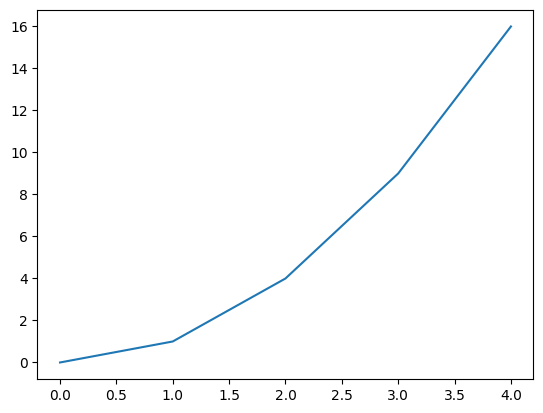

In [52]:
d = [0, 1, 4, 9, 16]

plt.plot(d);

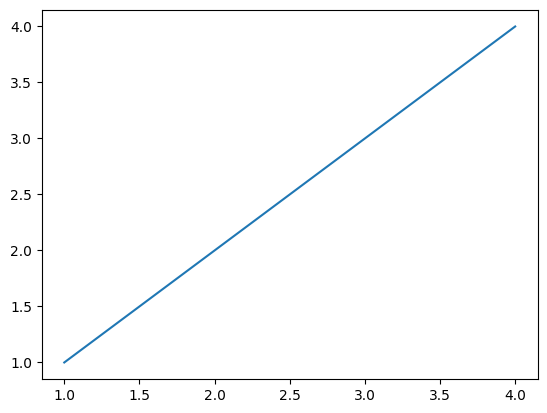

In [53]:
x = [1,2,3,4]
y = [1,2,3,4]

plt.plot(x,y)

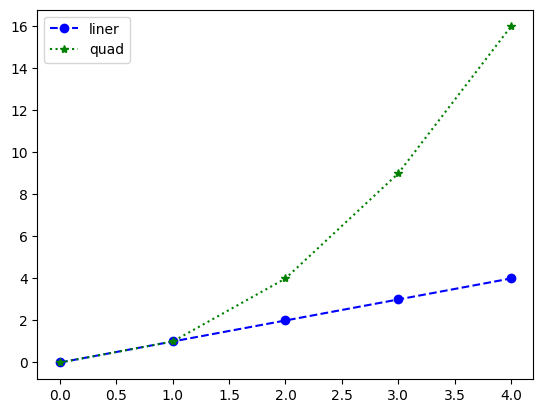

In [ ]:
data = [0,1,4,9,16]
x=[0,1,2,3,4]
y=[0,1,2,3,4]

plt.plot(x,y, linestyle = '--', color = 'blue', marker = 'o', label = "liner")
plt.plot(data, linestyle = ':', color = 'green', marker = '*', label = "quad")
# 左上に何かを示しすのを表示
plt.legend();

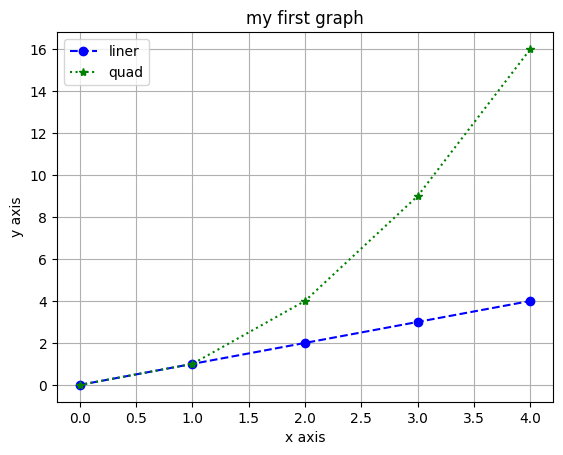

In [59]:
data = [0,1,4,9,16]
x=[0,1,2,3,4]
y=[0,1,2,3,4]

plt.plot(x,y, linestyle='--', color = 'blue', marker = 'o', label = "liner")
plt.plot(data, linestyle = ':', color = 'green', marker = '*', label = "quad")
plt.legend()
plt.title("my first graph")
plt.xlabel("x axis")
plt.ylabel("y axis")
plt.grid(True);

#### numpyを用いた科学計算からのグラフ

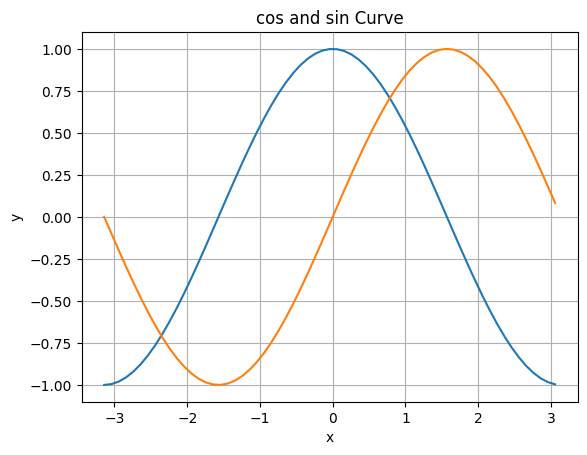

In [61]:
x = np.arange(-np.pi, np.pi, 0.1)

plt.plot(x, np.cos(x))
plt.plot(x, np.sin(x))

plt.title("cos and sin Curve")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True);

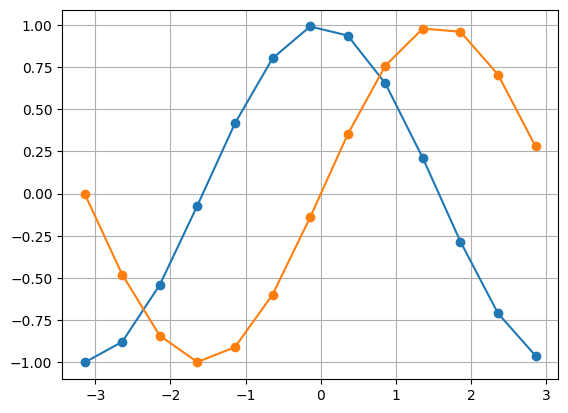

In [62]:
# 厳密には曲線は直線をつなぎ合わせて描写しているってのがわかるね〜
x=np.arange(-np.pi, np.pi, 0.5)

plt.plot(x, np.cos(x), marker='o')
plt.plot(x, np.sin(x), marker='o')
plt.grid(True);

### 4-2-2 散布図

- `plt.scatter()`を用いる

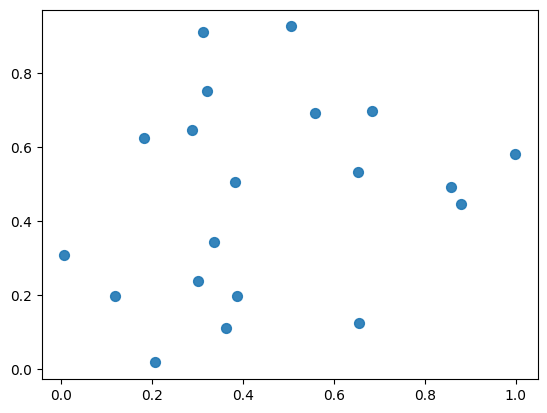

In [67]:
x=np.random.rand(20)
y=np.random.rand(20)
# sでサイズ、alphaで透明度
plt.scatter(x,y,s=50,alpha=0.9);

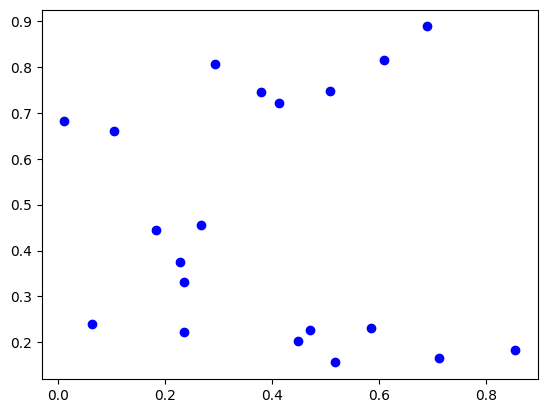

In [68]:
x=np.random.rand(20)
y=np.random.rand(20)

plt.plot(x,y,'o',color='blue');

### 4-2-3 棒グラフ

- `plt.bar()`を用いる

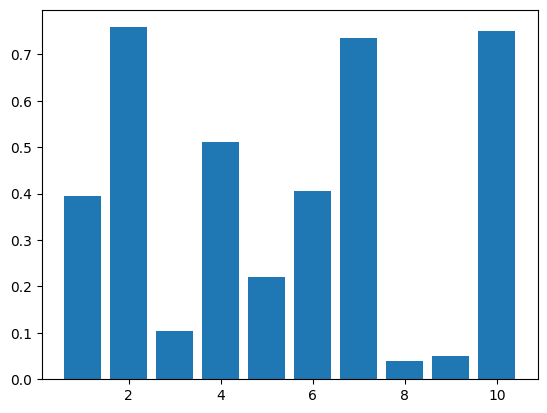

In [71]:
x=np.arange(1,11,1)
y=np.random.rand(10)

plt.bar(x,y);

### 4-2-4 ヒストグラム

- `plt.hist()`で


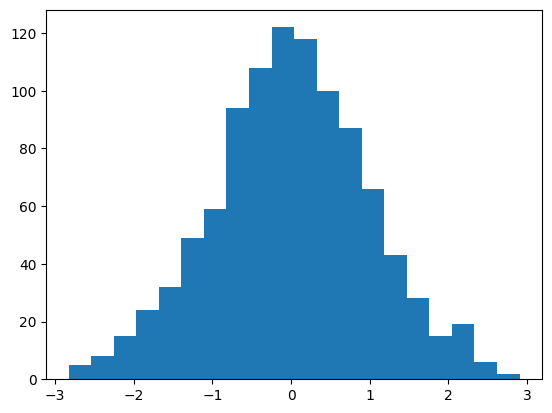

In [75]:
# randだと一様、randnで正規分布
d=np.random.randn(1000)

plt.hist(d, bins=20);

### 4-2-5 ヒートマップ
- `imshow()`関数で

[[0.59065981 0.48590088 0.98287549 0.96819634 0.81820333]
 [0.03880176 0.58801855 0.47608014 0.07433419 0.14950546]
 [0.82704794 0.16176652 0.26627504 0.66483339 0.53211416]
 [0.19518243 0.62399059 0.41397249 0.15461192 0.13704875]
 [0.01650635 0.29754649 0.9016093  0.7567004  0.27107974]]


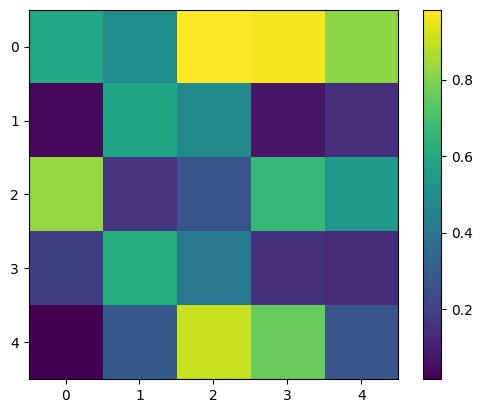

In [79]:
a = np.random.rand(25).reshape(5,5)
print(a)

im = plt.imshow(a)
plt.colorbar(im);

### 4-2-6 グラフ画像の出力

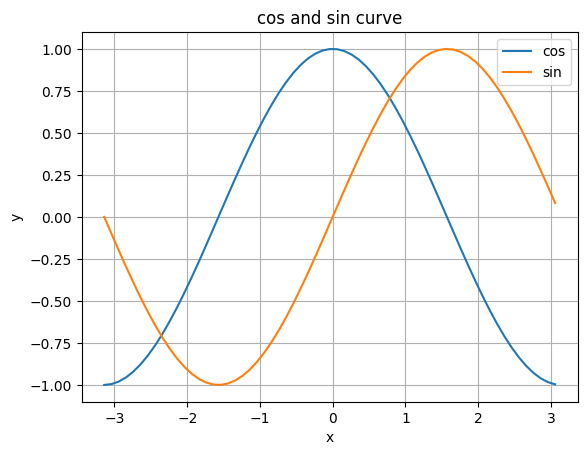

In [ ]:
x = np.arange(-np.pi, np.pi , 0.1)

plt.plot(x, np.cos(x), label='cos')
plt.plot(x, np.sin(x), label='sin')
plt.legend()
plt.title("cos and sin curve")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)

# savefigで保存
#plt.savefig('cos_sin.png')